# Milestone 4: Larger Sample Expansion and Advanced Kinematic Preparation

This notebook expands the Gaia–LAMOST workflow from a small pilot sample to a larger analysis-ready sample.

Main goals:

1. Define a larger Gaia–LAMOST sky-region strategy.
2. Import or query a larger LAMOST DR9 AFGKM stellar parameter sample.
3. Query Gaia DR3 data for the same sky region.
4. Perform Gaia–LAMOST source_id cross-match.
5. Validate coordinate consistency.
6. Reconstruct chemo-kinematic features from Milestone 3.
7. Prepare Galactic coordinates and UVW velocity inputs.
8. Save a larger analysis-ready feature table.
9. Generate validation figures.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u

In [4]:
PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

for path in [DATA_RAW, DATA_PROCESSED, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology')

## 1. Larger Sample Strategy

The previous pilot Gaia–LAMOST sample used a small sky region:

- RA: 120–122 deg
- DEC: 0–2 deg

For Milestone 4, we first adopt a conservative larger region:

- RA: 120–130 deg
- DEC: -5 to 5 deg

This is larger than the pilot region but still suitable for notebook-based workflow validation.

In [3]:
LARGER_SAMPLE_CONFIG = {
    "ra_min": 120.0,
    "ra_max": 130.0,
    "dec_min": -5.0,
    "dec_max": 5.0,
    "teff_min": 4000,
    "teff_max": 7000,
    "logg_min": 0.0,
    "logg_max": 5.0,
    "feh_min": -2.5,
    "feh_max": 0.8,
    "snrg_min": 30,
}

LARGER_SAMPLE_CONFIG

{'ra_min': 120.0,
 'ra_max': 130.0,
 'dec_min': -5.0,
 'dec_max': 5.0,
 'teff_min': 4000,
 'teff_max': 7000,
 'logg_min': 0.0,
 'logg_max': 5.0,
 'feh_min': -2.5,
 'feh_max': 0.8,
 'snrg_min': 30}

## 2. Larger LAMOST Sample

In this section, we will obtain or import a larger LAMOST DR9 AFGKM stellar parameter sample using the Milestone 4 sky-region and quality configuration.

Initial selection:

- RA: 120–130 deg
- DEC: -5 to 5 deg
- Teff: 4000–7000 K
- logg: 0.0–5.0
- [Fe/H]&#58; -2.5 to 0.8
- SNRg > 30

In [5]:
raw_files = sorted(DATA_RAW.glob("*"))
raw_files

[PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/.gitkeep'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_lamost_region_sample.csv'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_nearby_5000.csv'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/lamost_dr9_afgk_sample.csv')]

In [6]:
lamost_small_path = DATA_RAW / "lamost_dr9_afgk_sample.csv"

lamost_small = pd.read_csv(lamost_small_path, sep="|")

print(lamost_small.shape)
lamost_small.head()

(187, 27)


,combined_obsid,combined_designation,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_snru,combined_snrg,...,combined_ra,combined_dec,combined_feh,combined_feh_err,combined_logg,combined_logg_err,combined_rv_err,combined_rv,combined_teff,combined_teff_err
0,115109094,J080011.76+004925.7,2013-01-28,56321,56320,GAC119S00V1,9,94,31.78,137.99,...,120.04901,0.823831,-0.047,0.031,4.285,0.055,6.57,37.09,5876.56,40.85
1,115111043,J080012.30+013601.9,2013-01-28,56321,56320,GAC119S00V1,11,43,38.94,137.85,...,120.05127,1.600547,0.057,0.022,4.464,0.039,4.66,26.70,5964.22,28.97
2,115112029,J080154.61+012115.5,2013-01-28,56321,56320,GAC119S00V1,12,29,13.51,54.19,...,120.47757,1.354309,-0.154,0.018,4.068,0.030,2.87,35.49,5924.90,21.31
3,115113113,J080402.11+002927.2,2013-01-28,56321,56320,GAC119S00V1,13,113,18.82,96.90,...,121.00881,0.490915,0.285,0.018,4.460,0.030,3.08,22.88,5828.13,21.74
4,115312071,J080053.08+011034.0,2013-01-28,56321,56320,GAC119S00V3,12,71,15.68,81.19,...,120.22118,1.176120,0.083,0.025,4.560,0.042,4.05,-15.86,5747.09,29.98


In [7]:
list(lamost_small.columns)

['combined_obsid',
 'combined_designation',
 'combined_obsdate',
 'combined_lmjd',
 'combined_mjd',
 'combined_planid',
 'combined_spid',
 'combined_fiberid',
 'combined_snru',
 'combined_snrg',
 'combined_snrr',
 'combined_snri',
 'combined_snrz',
 'combined_class',
 'combined_subclass',
 'combined_z',
 'combined_gaia_source_id',
 'combined_ra',
 'combined_dec',
 'combined_feh',
 'combined_feh_err',
 'combined_logg',
 'combined_logg_err',
 'combined_rv_err',
 'combined_rv',
 'combined_teff',
 'combined_teff_err']

In [8]:
LAMOST_COLUMN_MAP = {
    "combined_gaia_source_id": "gaia_source_id",
    "combined_ra": "ra_lamost",
    "combined_dec": "dec_lamost",
    "combined_feh": "feh",
    "combined_feh_err": "feh_err",
    "combined_logg": "logg",
    "combined_logg_err": "logg_err",
    "combined_rv": "rv",
    "combined_rv_err": "rv_err",
    "combined_teff": "teff",
    "combined_teff_err": "teff_err",
    "combined_snrg": "snrg",
}

LAMOST_COLUMN_MAP

{'combined_gaia_source_id': 'gaia_source_id',
 'combined_ra': 'ra_lamost',
 'combined_dec': 'dec_lamost',
 'combined_feh': 'feh',
 'combined_feh_err': 'feh_err',
 'combined_logg': 'logg',
 'combined_logg_err': 'logg_err',
 'combined_rv': 'rv',
 'combined_rv_err': 'rv_err',
 'combined_teff': 'teff',
 'combined_teff_err': 'teff_err',
 'combined_snrg': 'snrg'}

In [9]:
def standardize_lamost_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename core LAMOST columns to shorter workflow-friendly names."""
    available_map = {
        old: new
        for old, new in LAMOST_COLUMN_MAP.items()
        if old in df.columns
    }
    return df.rename(columns=available_map)


lamost_small_std = standardize_lamost_columns(lamost_small)

print(lamost_small_std.shape)
lamost_small_std[
    ["gaia_source_id", "ra_lamost", "dec_lamost", "teff", "logg", "feh", "rv", "snrg"]
].head()

(187, 27)


,gaia_source_id,ra_lamost,dec_lamost,teff,logg,feh,rv,snrg
0,3084703137567209344,120.04901,0.823831,5876.56,4.285,-0.047,37.09,137.99
1,3084815974947636480,120.05127,1.600547,5964.22,4.464,0.057,26.70,137.85
2,3084751584798365184,120.47757,1.354309,5924.90,4.068,-0.154,35.49,54.19
3,3084433413620685056,121.00881,0.490915,5828.13,4.460,0.285,22.88,96.90
4,3084719389723324416,120.22118,1.176120,5747.09,4.560,0.083,-15.86,81.19


### 2.1 LAMOST Larger Sample Query Plan

The larger LAMOST sample will use the following initial selection:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
Teff: 4000–7000 K
logg: 0.0–5.0
[Fe/H]: -2.5 to 0.8
SNRg > 30

In [10]:
lamost_larger_path = DATA_RAW / "lamost_dr9_larger_sample.csv"

print(lamost_larger_path)
print("Exists:", lamost_larger_path.exists())

/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/lamost_dr9_larger_sample.csv
Exists: False


### 2.2 Current LAMOST Data Status

The existing Milestone 2 notebook imported a local LAMOST file:

```text
data/raw/lamost_dr9_afgk_sample.csv
```

No online LAMOST query code was stored in the previous notebook. Therefore, for Milestone 4, the larger LAMOST sample needs to be obtained separately and saved as:

```text
data/raw/lamost_dr9_larger_sample.csv
```

The Gaia DR3 query workflow can still be reused with `astroquery.gaia`.

In [11]:
def read_lamost_sample(path: Path) -> pd.DataFrame:
    """Read a LAMOST sample file and standardize core columns."""
    if not path.exists():
        raise FileNotFoundError(f"LAMOST file not found: {path}")

    # LAMOST exported CSV files in this project are pipe-separated.
    df = pd.read_csv(path, sep="|")

    df = standardize_lamost_columns(df)

    numeric_cols = [
        "ra_lamost",
        "dec_lamost",
        "snrg",
        "teff",
        "teff_err",
        "logg",
        "logg_err",
        "feh",
        "feh_err",
        "rv",
        "rv_err",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "gaia_source_id" in df.columns:
        df["gaia_source_id"] = df["gaia_source_id"].astype(str)

    return df

In [12]:
lamost_small_test = read_lamost_sample(DATA_RAW / "lamost_dr9_afgk_sample.csv")

print(lamost_small_test.shape)
lamost_small_test[
    ["gaia_source_id", "ra_lamost", "dec_lamost", "teff", "logg", "feh", "rv", "snrg"]
].head()

(187, 27)


,gaia_source_id,ra_lamost,dec_lamost,teff,logg,feh,rv,snrg
0,3084703137567209344,120.04901,0.823831,5876.56,4.285,-0.047,37.09,137.99
1,3084815974947636480,120.05127,1.600547,5964.22,4.464,0.057,26.70,137.85
2,3084751584798365184,120.47757,1.354309,5924.90,4.068,-0.154,35.49,54.19
3,3084433413620685056,121.00881,0.490915,5828.13,4.460,0.285,22.88,96.90
4,3084719389723324416,120.22118,1.176120,5747.09,4.560,0.083,-15.86,81.19


In [13]:
if lamost_larger_path.exists():
    lamost_larger = read_lamost_sample(lamost_larger_path)
    print("Loaded larger LAMOST sample:", lamost_larger.shape)
else:
    lamost_larger = None
    print("Larger LAMOST sample not found.")
    print("Expected file:")
    print(lamost_larger_path)

Larger LAMOST sample not found.
Expected file:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/lamost_dr9_larger_sample.csv


## 3. Gaia DR3 Larger Region Query

Because the larger LAMOST sample is not available yet, we first prepare the Gaia DR3 query workflow for the same sky region.

The Gaia query will use the Milestone 4 region:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
```

Quality filters:

```text
parallax IS NOT NULL
parallax > 0
parallax_over_error > 5
pmra IS NOT NULL
pmdec IS NOT NULL
phot_g_mean_mag IS NOT NULL
bp_rp IS NOT NULL
ruwe < 1.4
```

The raw Gaia output will be saved as:

```text
data/raw/gaia_dr3_larger_lamost_region_sample.csv
```

The processed Gaia table with distance and absolute magnitude will be saved as:

```text
data/processed/gaia_dr3_larger_lamost_region_with_features.csv
```

In [14]:
gaia_larger_raw_path = DATA_RAW / "gaia_dr3_larger_lamost_region_sample.csv"
gaia_larger_features_path = DATA_PROCESSED / "gaia_dr3_larger_lamost_region_with_features.csv"

print("Raw Gaia path:")
print(gaia_larger_raw_path)
print("Exists:", gaia_larger_raw_path.exists())

print("\nProcessed Gaia path:")
print(gaia_larger_features_path)
print("Exists:", gaia_larger_features_path.exists())

Raw Gaia path:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_larger_lamost_region_sample.csv
Exists: False

Processed Gaia path:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Exists: False


In [16]:
LARGER_SAMPLE_CONFIG = {
    "ra_min": 120.0,
    "ra_max": 130.0,
    "dec_min": -5.0,
    "dec_max": 5.0,
    "teff_min": 4000,
    "teff_max": 7000,
    "logg_min": 0.0,
    "logg_max": 5.0,
    "feh_min": -2.5,
    "feh_max": 0.8,
    "snrg_min": 30,
}

LARGER_SAMPLE_CONFIG

{'ra_min': 120.0,
 'ra_max': 130.0,
 'dec_min': -5.0,
 'dec_max': 5.0,
 'teff_min': 4000,
 'teff_max': 7000,
 'logg_min': 0.0,
 'logg_max': 5.0,
 'feh_min': -2.5,
 'feh_max': 0.8,
 'snrg_min': 30}

In [17]:
gaia_larger_region = {
    "ra_min": LARGER_SAMPLE_CONFIG["ra_min"],
    "ra_max": LARGER_SAMPLE_CONFIG["ra_max"],
    "dec_min": LARGER_SAMPLE_CONFIG["dec_min"],
    "dec_max": LARGER_SAMPLE_CONFIG["dec_max"],
}

gaia_larger_region

{'ra_min': 120.0, 'ra_max': 130.0, 'dec_min': -5.0, 'dec_max': 5.0}

In [18]:
from astroquery.gaia import Gaia

Gaia.MAIN_GAIA_TABLE

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [19]:
gaia_larger_query = f"""
SELECT TOP 50000
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {gaia_larger_region["ra_min"]} AND {gaia_larger_region["ra_max"]}
  AND dec BETWEEN {gaia_larger_region["dec_min"]} AND {gaia_larger_region["dec_max"]}
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4
"""

print(gaia_larger_query)


SELECT TOP 50000
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 120.0 AND 130.0
  AND dec BETWEEN -5.0 AND 5.0
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4



In [20]:
job = Gaia.launch_job_async(gaia_larger_query)
gaia_larger_sample = job.get_results().to_pandas()

gaia_larger_sample.shape

INFO: Query finished. [astroquery.utils.tap.core]


(50000, 10)

In [21]:
print(gaia_larger_sample.shape)
print(gaia_larger_sample.columns.tolist())

gaia_larger_sample.head()

(50000, 10)
['source_id', 'ra', 'dec', 'parallax', 'parallax_over_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'ruwe']


,source_id,ra,dec,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe
0,582377022509842432,129.997365,4.330521,1.262691,82.372955,-3.621171,-1.707824,13.298033,0.649304,1.009259
1,582389323296182144,129.904558,4.339808,1.078683,9.667572,-2.989947,8.413037,17.888172,1.744074,1.045913
2,582391316161005568,129.874323,4.446491,0.729568,26.749847,3.778731,3.886912,15.132143,0.772429,0.962967
3,582391384880481152,129.897317,4.457419,2.291102,126.445618,10.032053,-6.796543,14.061455,1.070021,1.025608
4,582392827989487616,129.956930,4.472501,1.231150,50.072922,-2.248961,0.291924,14.788934,0.887146,0.983454


In [22]:
gaia_larger_sample.to_csv(gaia_larger_raw_path, index=False)

print("Saved Gaia larger raw sample:")
print(gaia_larger_raw_path)
print("Shape:", gaia_larger_sample.shape)

Saved Gaia larger raw sample:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: (50000, 10)


In [23]:
gaia_larger_sample["distance_pc"] = 1000.0 / gaia_larger_sample["parallax"]

gaia_larger_sample["absolute_g_mag"] = (
    gaia_larger_sample["phot_g_mean_mag"]
    - 5 * np.log10(gaia_larger_sample["distance_pc"])
    + 5
)

gaia_larger_sample[[
    "parallax",
    "distance_pc",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "bp_rp"
]].describe()

,parallax,distance_pc,phot_g_mean_mag,absolute_g_mag,bp_rp
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.088271,1507.113655,16.231575,5.807324,1.279463
std,1.106052,960.342822,1.729392,2.536134,0.617980
min,0.073095,23.467779,5.468879,-3.591599,-0.547195
25%,0.489611,771.388868,15.258916,4.044244,0.828267
50%,0.742896,1346.082713,16.358489,5.418878,1.048007
75%,1.296363,2042.436705,17.389396,7.383585,1.602952
max,42.611617,13680.819161,20.704451,15.984145,4.652884


In [24]:
gaia_larger_sample.to_csv(gaia_larger_features_path, index=False)

print("Saved Gaia larger feature table:")
print(gaia_larger_features_path)
print("Shape:", gaia_larger_sample.shape)

Saved Gaia larger feature table:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: (50000, 12)


### 3.1 Gaia Larger Sample Query Summary

The Gaia DR3 larger-region query was successfully completed.

Query region:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
```

Quality filters:

```text
parallax > 0
parallax_over_error > 5
pmra and pmdec available
phot_g_mean_mag and bp_rp available
ruwe < 1.4
```

Output:

```text
Raw Gaia larger sample:
data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: 50000 stars × 10 columns

Processed Gaia larger feature table:
data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: 50000 stars × 12 columns
```

Added features:

```text
distance_pc
absolute_g_mag
```

Note:

The query used `SELECT TOP 50000`, and the result reached this limit. Therefore, the selected sky region likely contains at least 50,000 Gaia DR3 sources after quality filtering.

## 4. Gaia Larger Sample Validation Plots

Before the larger LAMOST sample is available, we first validate the Gaia larger-region sample.

The first validation figure checks the sky coverage in equatorial coordinates:

```text
RA vs DEC
```

This confirms that the Gaia sample covers the intended Milestone 4 sky region.

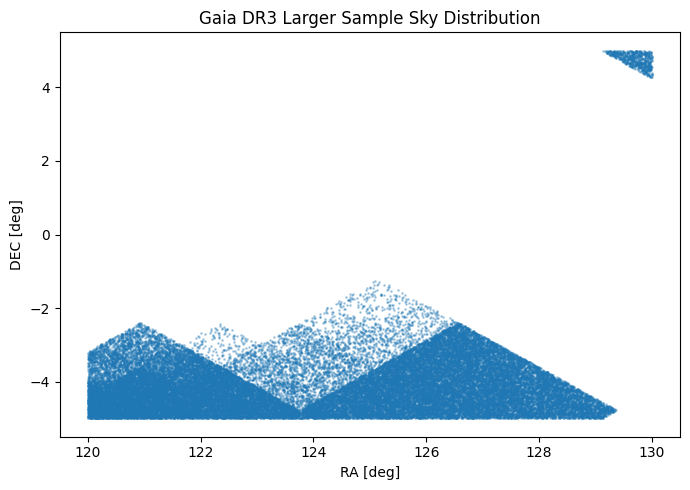

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_sky_distribution.png')

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(
    gaia_larger_sample["ra"],
    gaia_larger_sample["dec"],
    s=1,
    alpha=0.3
)

plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.title("Gaia DR3 Larger Sample Sky Distribution")

plt.tight_layout()

gaia_larger_sky_path = FIGURES / "gaia_lamost_larger_sky_distribution.png"
plt.savefig(gaia_larger_sky_path, dpi=200)

plt.show()

gaia_larger_sky_path

### 4.1 Sky Distribution Note

The Gaia larger-sample sky distribution confirms that the query reached the intended general sky region.

However, the coverage is not spatially uniform across the full RA–DEC rectangle.

This is likely because the query used:

```text
SELECT TOP 50000
```

Therefore, the current Gaia larger sample should be interpreted as a truncated subset of the full quality-filtered region, rather than a complete spatially uniform sample of all Gaia DR3 sources in this sky area.

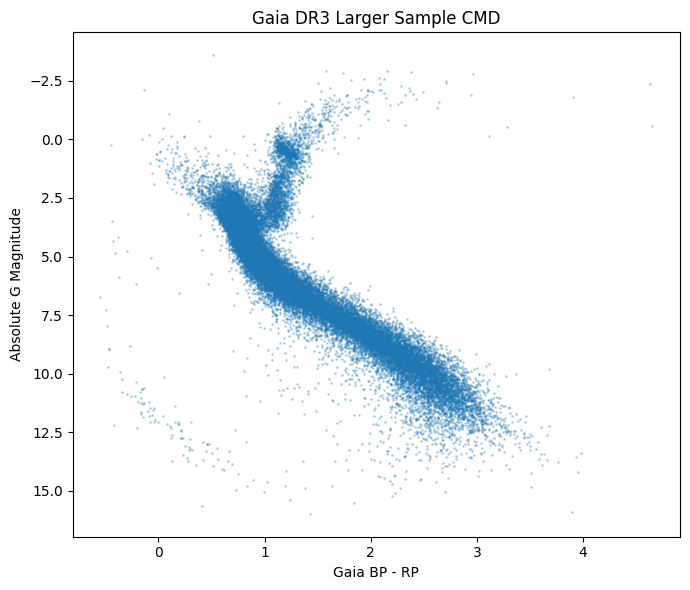

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_cmd.png')

In [27]:
plt.figure(figsize=(7, 6))

plt.scatter(
    gaia_larger_sample["bp_rp"],
    gaia_larger_sample["absolute_g_mag"],
    s=1,
    alpha=0.25
)

plt.gca().invert_yaxis()

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute G Magnitude")
plt.title("Gaia DR3 Larger Sample CMD")

plt.tight_layout()

gaia_larger_cmd_path = FIGURES / "gaia_lamost_larger_cmd.png"
plt.savefig(gaia_larger_cmd_path, dpi=200)

plt.show()

gaia_larger_cmd_path

### 4.2 CMD Validation Note

The Gaia larger-sample CMD shows the expected broad stellar-population structure.

Visible features include:

```text
- a clear main sequence
- a red giant branch
- a sparse population of outliers
```

This indicates that the basic Gaia feature construction is working properly, especially for:

```text
distance_pc
absolute_g_mag
bp_rp
```

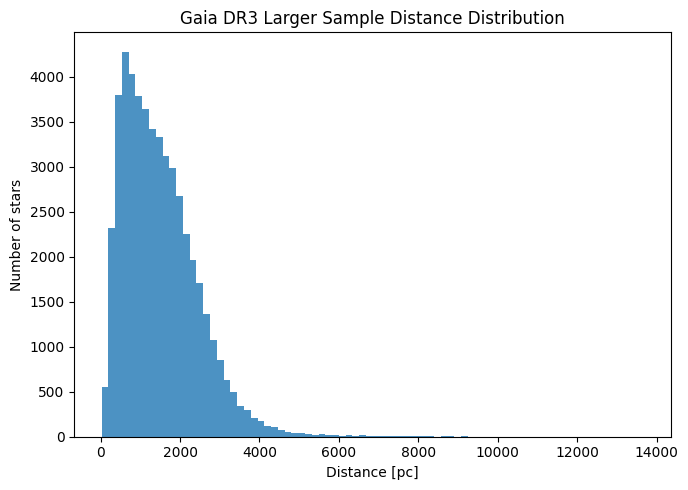

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_distance_distribution.png')

In [28]:
plt.figure(figsize=(7, 5))

plt.hist(
    gaia_larger_sample["distance_pc"],
    bins=80,
    alpha=0.8
)

plt.xlabel("Distance [pc]")
plt.ylabel("Number of stars")
plt.title("Gaia DR3 Larger Sample Distance Distribution")

plt.tight_layout()

gaia_larger_distance_path = FIGURES / "gaia_lamost_larger_distance_distribution.png"
plt.savefig(gaia_larger_distance_path, dpi=200)

plt.show()

gaia_larger_distance_path

### 4.3 Distance Distribution Note

The Gaia larger-sample distance distribution is strongly right-skewed.

Main observations:

```text
- most stars are concentrated at relatively nearby distances
- the distribution shows a long tail toward larger distances
- this is consistent with the parallax-based distance summary statistics
```

This supports that the basic distance construction:

```text
distance_pc = 1000 / parallax
```

is working as expected for the current Gaia larger sample.

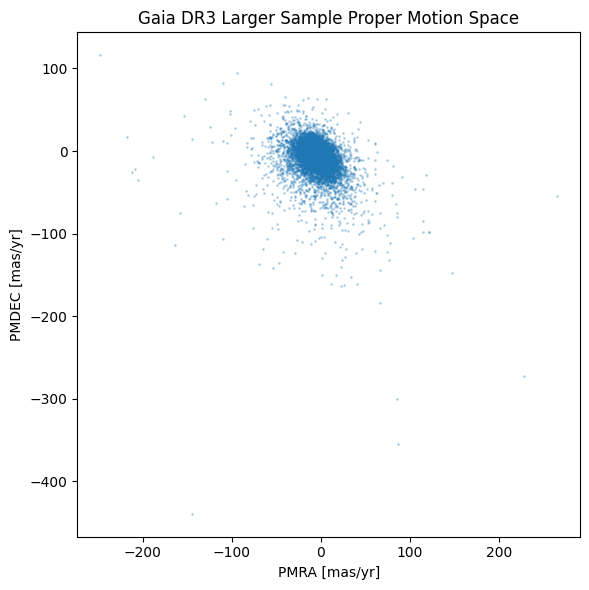

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_proper_motion_space.png')

In [29]:
plt.figure(figsize=(6, 6))

plt.scatter(
    gaia_larger_sample["pmra"],
    gaia_larger_sample["pmdec"],
    s=1,
    alpha=0.25
)

plt.xlabel("PMRA [mas/yr]")
plt.ylabel("PMDEC [mas/yr]")
plt.title("Gaia DR3 Larger Sample Proper Motion Space")

plt.tight_layout()

gaia_larger_pm_path = FIGURES / "gaia_lamost_larger_proper_motion_space.png"
plt.savefig(gaia_larger_pm_path, dpi=200)

plt.show()

gaia_larger_pm_path

### 4.4 Proper Motion Space Note

The Gaia larger-sample proper motion distribution appears broadly well-behaved.

Main observations:

```text
- most stars are concentrated in a compact central proper-motion region
- a small number of outliers extend to larger absolute proper motions
- no major structural problems are visible in the pmra–pmdec plane
```

This suggests that the Gaia proper-motion measurements:

```text
pmra
pmdec
```

are suitable for the next-stage kinematic preparation.

## 5. Interim Milestone 4 Summary

At this stage, Milestone 4 has completed the Gaia-side larger sample preparation.

Completed tasks:

```text
1. Created notebooks/04_larger_sample_kinematic_preparation.ipynb
2. Defined the larger sample sky region
3. Prepared reusable LAMOST column-standardization and reading functions
4. Confirmed that the larger LAMOST sample is not yet available locally
5. Queried Gaia DR3 for the larger Milestone 4 sky region
6. Saved the Gaia larger raw sample
7. Constructed basic Gaia features
8. Saved the Gaia larger processed feature table
9. Generated Gaia larger validation plots
```

Gaia larger sample outputs:

```text
data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: 50000 stars × 10 columns

data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: 50000 stars × 12 columns
```

Generated figures:

```text
figures/gaia_lamost_larger_sky_distribution.png
figures/gaia_lamost_larger_cmd.png
figures/gaia_lamost_larger_distance_distribution.png
figures/gaia_lamost_larger_proper_motion_space.png
```

Current limitation:

```text
The larger LAMOST sample has not yet been obtained.
```

Next steps:

```text
1. Obtain or import data/raw/lamost_dr9_larger_sample.csv
2. Read and standardize the larger LAMOST sample
3. Perform Gaia–LAMOST source_id cross-match
4. Validate coordinate separation
5. Construct larger-sample chemo-kinematic features
6. Prepare Galactic coordinates and UVW input fields
```